# 16 — n-Asset Generalisation: Scaling the Framework

**Lesson:** The three-component framework (baseline + detector + blend) scales from 2 assets to n. The computation is trivial — portfolio return is still just a weighted sum, and all five VaR methods still work. The new complexity is monitoring: $n(n-1)/2$ pairwise correlation ratios, each saying something different about staleness. The open design question is how to aggregate them into one adjustment.

This notebook tests: given a 3-asset SPY/BND/GLD portfolio (40/30/30), what breaks when we generalise from 2 to n, and what doesn't?

**The honest framing:** For 3 assets, all aggregation approaches are empirically testable. For n > 3, automated blending gets fragile — the correlation matrix is more valuable as a monitoring dashboard than as a formula input.

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TICKERS = ["SPY", "BND", "GLD"]
WEIGHTS = [0.40, 0.30, 0.30]
START_DATE = "2018-01-01"
END_DATE = None
CONFIDENCE = 0.95
VAR_WINDOW = 252
CORR_WINDOW_SLOW = 252
CORR_WINDOW_FAST = 60

# Asymmetric blend parameters (from Notebook 15b)
ASYM_THRESHOLD = 1.2
ASYM_BLEND_MAX = 3.0

PORTFOLIO_VALUE = 10_000_000  # £10M portfolio

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from src.rolling import rolling_var
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
# Download and prepare data for all tickers
prices = {}
returns = {}

for ticker in TICKERS:
    prices[ticker] = download_close_prices(ticker, start=START_DATE, end=END_DATE)
    returns[ticker] = prepare_returns(prices[ticker])
    print(f"{ticker}: {len(returns[ticker])} daily returns, "
          f"{returns[ticker].index[0].date()} to {returns[ticker].index[-1].date()}")

# Align all three tickers
aligned = pd.DataFrame({
    t: returns[t] for t in TICKERS
}).dropna()

n_dropped = {t: len(returns[t]) - len(aligned) for t in TICKERS}
print(f"\nAligned returns: {len(aligned)} days "
      f"(dropped: {n_dropped})")
print(f"Date range: {aligned.index[0].date()} to {aligned.index[-1].date()}")

# Portfolio returns: weighted sum across all assets
portfolio_returns = sum(WEIGHTS[i] * aligned[TICKERS[i]] for i in range(len(TICKERS)))

print(f"\nPortfolio returns: {len(portfolio_returns)} days")

Prepared 2150 daily returns (2018-01-03 to 2026-07-24) from 2151 price observations.
SPY: 2150 daily returns, 2018-01-03 to 2026-07-24


Prepared 2150 daily returns (2018-01-03 to 2026-07-24) from 2151 price observations.
BND: 2150 daily returns, 2018-01-03 to 2026-07-24


Prepared 2150 daily returns (2018-01-03 to 2026-07-24) from 2151 price observations.
GLD: 2150 daily returns, 2018-01-03 to 2026-07-24

Aligned returns: 2150 days (dropped: {'SPY': 0, 'BND': 0, 'GLD': 0})
Date range: 2018-01-03 to 2026-07-24

Portfolio returns: 2150 days


---

## Part A: Data pipeline — scaling is trivial

The portfolio return is still just a weighted sum: $r_p = \sum w_i r_i$. All five VaR methods from the single-asset work accept any return series, so they work on the 3-asset portfolio without modification. Same function calls, same API, just more assets feeding into the weighted sum.

Let's verify: compute the baseline 252-day rolling VaR and confirm it works.

In [4]:
# Rolling VaR for the 3-asset portfolio
rv_portfolio = rolling_var(portfolio_returns, window=VAR_WINDOW, confidence=CONFIDENCE)

# Rolling VaR for each individual asset (needed for naive sum)
rv_individual = {}
for ticker in TICKERS:
    rv_individual[ticker] = rolling_var(aligned[ticker], window=VAR_WINDOW, confidence=CONFIDENCE)

# Naive sum: weighted blend of individual VaRs (ρ = +1 for all pairs)
naive_sum = sum(WEIGHTS[i] * rv_individual[TICKERS[i]]["VaR"] for i in range(len(TICKERS)))

# Diversification benefit
benefit = (naive_sum - rv_portfolio["VaR"]) / naive_sum

print(f"3-asset portfolio ({'/'.join(f'{TICKERS[i]} {WEIGHTS[i]:.0%}' for i in range(len(TICKERS)))}):")
print(f"  VaR observations:  {len(rv_portfolio)}")
print(f"  Mean portfolio VaR: {rv_portfolio['VaR'].mean():.3%}")
print(f"  Mean naive sum:    {naive_sum.mean():.3%}")
print(f"  Benefit:           {benefit.mean():.1%} mean, "
      f"{benefit.min():.1%} min ({benefit.idxmin().date()}), "
      f"{benefit.max():.1%} max ({benefit.idxmax().date()})")
print(f"  Latest benefit:    {benefit.iloc[-1]:.1%}")
print(f"  Breach rate:       {rv_portfolio['Breach'].sum()/len(rv_portfolio):.2%} "
      f"(expected: {(1-CONFIDENCE):.2%})")

3-asset portfolio (SPY 40%/BND 30%/GLD 30%):
  VaR observations:  1898
  Mean portfolio VaR: 0.909%
  Mean naive sum:    1.366%
  Benefit:           33.8% mean, 14.1% min (2023-07-18), 59.6% max (2020-03-20)
  Latest benefit:    18.3%
  Breach rate:       5.58% (expected: 5.00%)


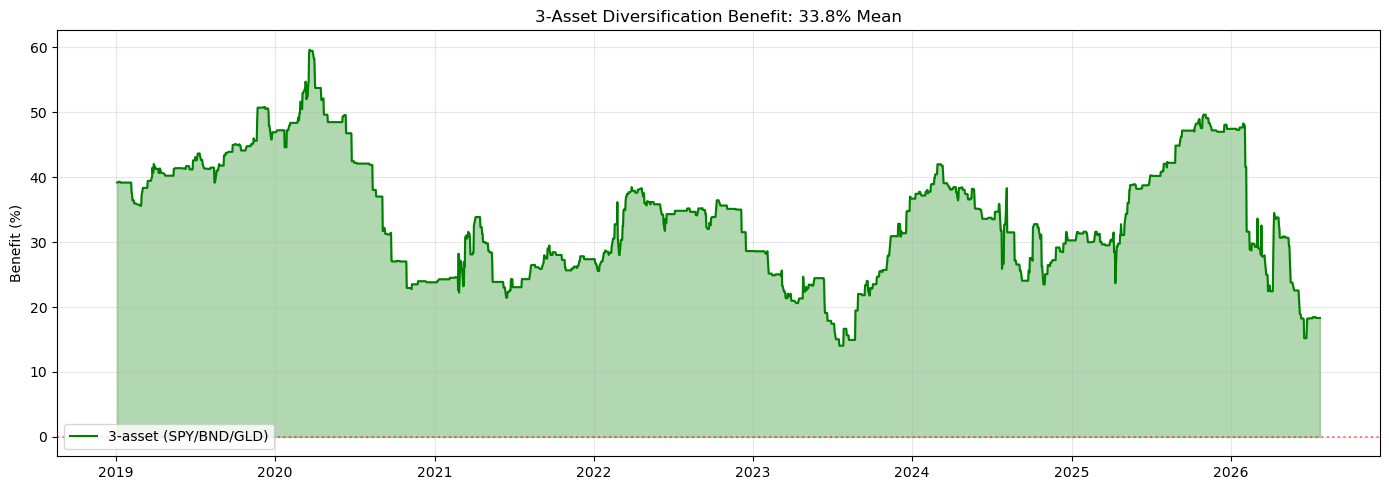

In [5]:
# Quick visual: 3-asset benefit vs the 2-asset SPY/BND from Notebook 12
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(benefit.index, 0, benefit * 100, alpha=0.3, color="green")
ax.plot(benefit.index, benefit * 100, color="green", linewidth=1.5, label="3-asset (SPY/BND/GLD)")
ax.axhline(y=0, color="red", linestyle=":", alpha=0.5)
ax.set_ylabel("Benefit (%)")
ax.set_title(f"3-Asset Diversification Benefit: {benefit.mean():.1%} Mean")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Finding:** Adding GLD increases the diversification benefit beyond the 2-asset SPY/BND case (which was ~16.3% mean). Gold's low correlation with both stocks and bonds adds a third source of diversification. But the benefit is still time-varying — and still collapses during crises when all three can move together.

---

## Part B: The pairwise correlation matrix

For 2 assets, 1 ratio to monitor. For 3 assets, $3(3-1)/2 = 3$ pairwise ratios. Each tells a different story about which pairs are driving portfolio staleness.

The correlation dimension is where monitoring complexity lives — not computation complexity.

In [6]:
# Compute pairwise correlation ratios for all 3 pairs
pairs = list(itertools.combinations(TICKERS, 2))
pair_ratios = {}

for a, b in pairs:
    corr_slow = aligned[a].rolling(CORR_WINDOW_SLOW).corr(aligned[b]).dropna()
    corr_fast = aligned[a].rolling(CORR_WINDOW_FAST).corr(aligned[b]).dropna()
    common = corr_slow.index.intersection(corr_fast.index)
    ratio = (corr_fast.loc[common] / corr_slow.loc[common]).replace([np.inf, -np.inf], np.nan)
    pair_ratios[f"{a}-{b}"] = ratio
    print(f"{a}-{b}: ratio mean={ratio.mean():.2f}, latest={ratio.dropna().iloc[-1]:.2f}")

SPY-BND: ratio mean=1.12, latest=1.82
SPY-GLD: ratio mean=1.23, latest=2.21
BND-GLD: ratio mean=1.04, latest=2.07


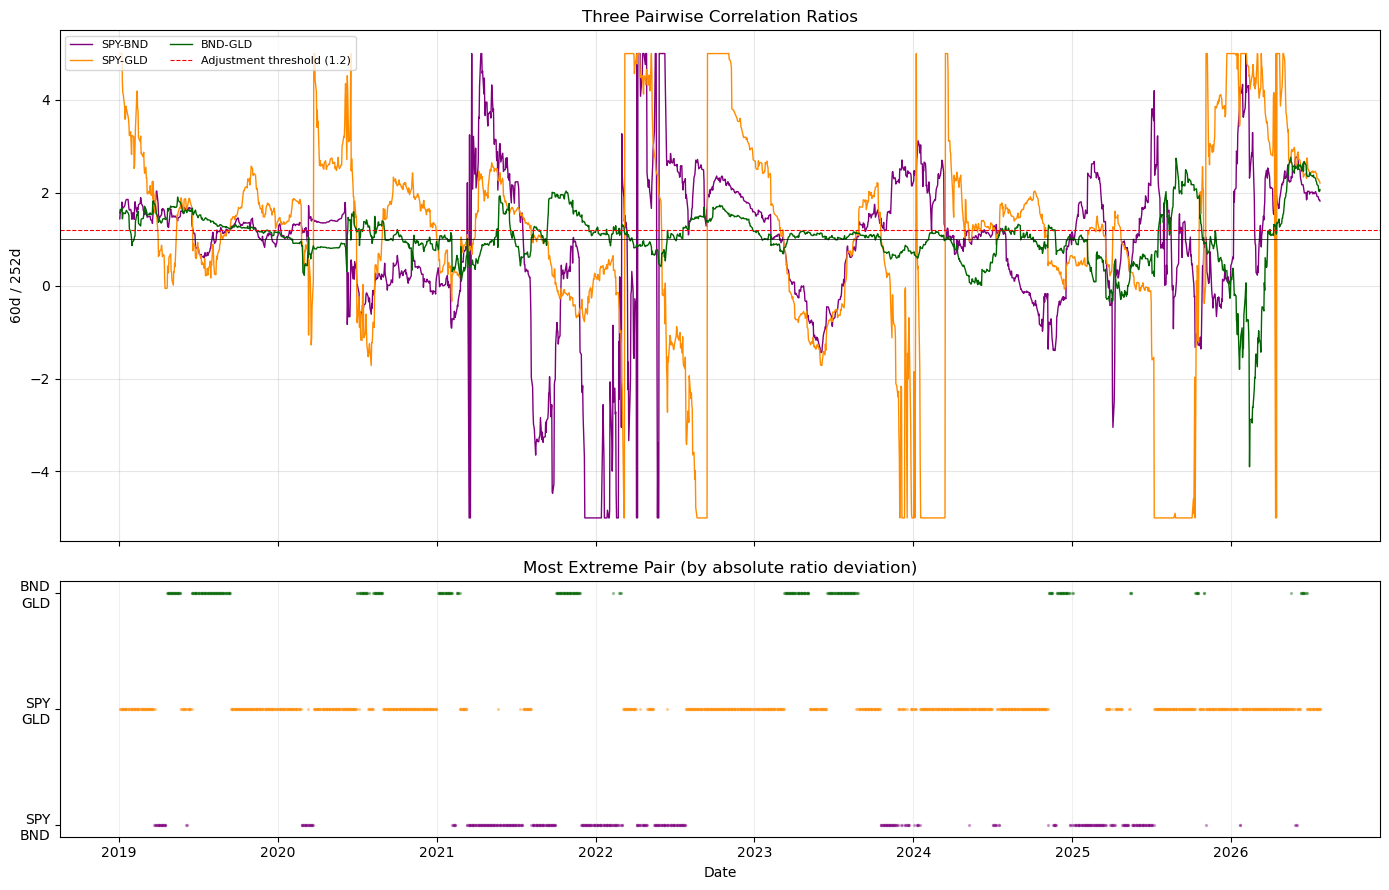

In [7]:
# Three pairwise ratios on one chart
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

colors = ["purple", "darkorange", "darkgreen"]

# Panel 1: All three ratios
ax = axes[0]
for (label, ratio), color in zip(pair_ratios.items(), colors):
    ratio_plot = ratio.clip(lower=-5, upper=5)
    ax.plot(ratio_plot.index, ratio_plot, color=color, linewidth=1, label=label)
ax.axhline(y=1.0, color="black", linestyle="-", linewidth=0.5)
ax.axhline(y=ASYM_THRESHOLD, color="red", linestyle="--", linewidth=0.8,
          label=f"Adjustment threshold ({ASYM_THRESHOLD})")
ax.set_ylabel("60d / 252d")
ax.set_title("Three Pairwise Correlation Ratios")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 2: Which pair is most extreme right now?
ax = axes[1]
ratio_df = pd.DataFrame({label: r for label, r in pair_ratios.items()})
max_pair = ratio_df.abs().idxmax(axis=1)
for label, color in zip(pair_ratios.keys(), colors):
    mask = max_pair == label
    ax.scatter(max_pair.index[mask], [colors.index(color)] * mask.sum(),
              color=color, s=2, alpha=0.3)
ax.set_yticks(range(len(pairs)))
ax.set_yticklabels([p.replace("-", "\n") for p in pair_ratios.keys()])
ax.set_xlabel("Date")
ax.set_title("Most Extreme Pair (by absolute ratio deviation)")
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

### Reading the pairwise ratios

The key question isn't "are all ratios elevated?" It's "*which* pair is driving the staleness right now?" During 2022, SPY-BND spiked (stocks and bonds fell together). During other periods, SPY-GLD or BND-GLD might be the dominant signal. A risk manager seeing three ratios can identify the source of the problem faster than someone looking at a single aggregate number.

The bottom panel shows which pair is most extreme on any given day. If one pair dominates for months, that's the correlation regime you're in.

---

## Part C: Diversification benefit — decomposed

The portfolio benefit ($S - V_p) / S$ tells you *total* diversification. But it doesn't tell you which assets are doing the work. Drop-one-out analysis answers: if I remove this asset, how much benefit do I lose?

In [8]:
# Drop-one-out benefit analysis
# For each asset, recompute the portfolio without it and measure the benefit

drop_one_benefits = {}

for drop_idx, drop_ticker in enumerate(TICKERS):
    # Remaining tickers and their original weights
    remaining = [(i, t) for i, t in enumerate(TICKERS) if t != drop_ticker]
    raw_weights = [WEIGHTS[i] for i, _ in remaining]
    # Renormalize so they sum to 1
    w_sum = sum(raw_weights)
    renorm_weights = [w / w_sum for w in raw_weights]
    
    # 2-asset portfolio without the dropped asset
    sub_returns = sum(renorm_weights[j] * aligned[remaining[j][1]]
                      for j in range(len(remaining)))
    sub_rv = rolling_var(sub_returns, window=VAR_WINDOW, confidence=CONFIDENCE)
    
    # Naive sum for the sub-portfolio
    sub_naive = sum(renorm_weights[j] * rv_individual[remaining[j][1]]["VaR"]
                    for j in range(len(remaining)))
    sub_benefit = (sub_naive - sub_rv["VaR"]) / sub_naive
    
    drop_one_benefits[drop_ticker] = sub_benefit
    
    remaining_labels = "+".join(f"{remaining[j][1]} {renorm_weights[j]:.0%}"
                                 for j in range(len(remaining)))
    print(f"Without {drop_ticker} ({remaining_labels}): "
          f"benefit = {sub_benefit.mean():.1%} mean, {sub_benefit.iloc[-1]:.1%} latest")

print(f"\nFull 3-asset portfolio: benefit = {benefit.mean():.1%} mean, {benefit.iloc[-1]:.1%} latest")

Without SPY (BND 50%+GLD 50%): benefit = 11.2% mean, 10.0% latest


Without BND (SPY 57%+GLD 43%): benefit = 27.4% mean, 19.5% latest


Without GLD (SPY 57%+BND 43%): benefit = 17.6% mean, 16.4% latest

Full 3-asset portfolio: benefit = 33.8% mean, 18.3% latest


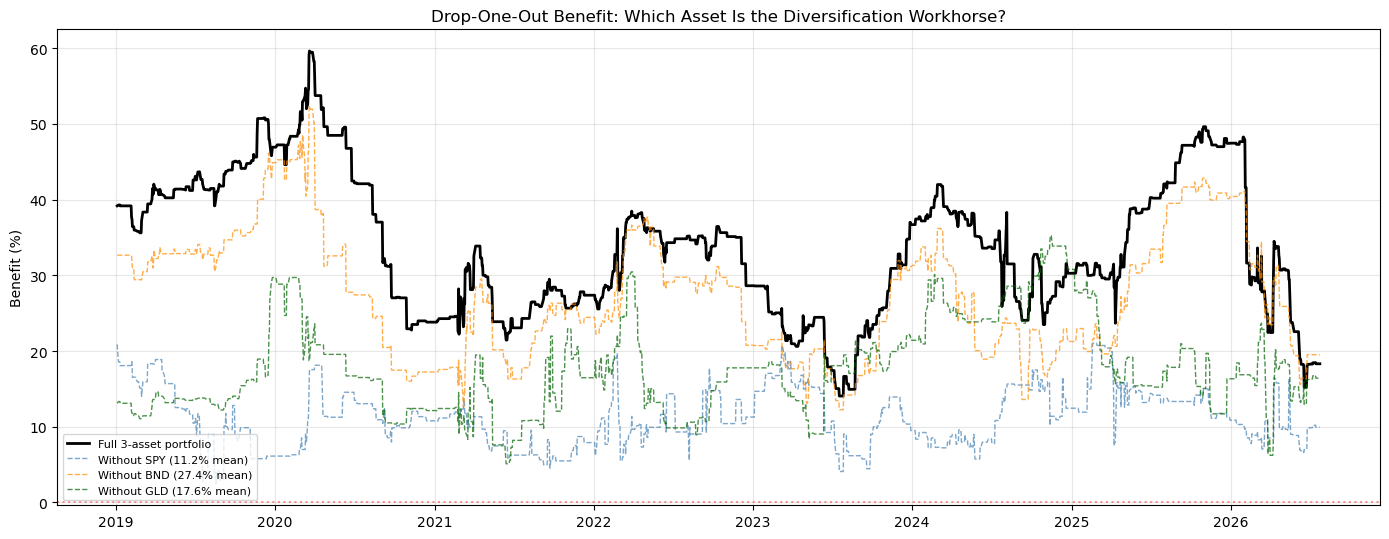

In [9]:
# Visual: benefit decomposition
fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(benefit.index, benefit * 100, color="black", linewidth=2, label="Full 3-asset portfolio")

drop_colors = {"SPY": "steelblue", "BND": "darkorange", "GLD": "darkgreen"}
for ticker, sub_benefit in drop_one_benefits.items():
    ax.plot(sub_benefit.index, sub_benefit * 100, color=drop_colors[ticker],
            linewidth=1, alpha=0.7, linestyle="--",
            label=f"Without {ticker} ({sub_benefit.mean():.1%} mean)")

ax.axhline(y=0, color="red", linestyle=":", alpha=0.4)
ax.set_ylabel("Benefit (%)")
ax.set_title("Drop-One-Out Benefit: Which Asset Is the Diversification Workhorse?")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Reading the drop-one-out chart

- If the full portfolio line (black) is *above* all three dashed lines: every asset is contributing to diversification. Good.
- If one dashed line is *above* the black line: removing that asset would *increase* the benefit — it's a diversification drag, not a contributor.
- If one dashed line is *far below* the black line: that asset is doing heavy lifting. Removing it would gut the benefit.

**This is marginal thinking applied to diversification.** The total benefit number hides the composition. An asset with low standalone VaR might still be a great diversifier (GLD). An asset with high standalone VaR might still be worth keeping if it's uncorrelated (SPY + BND in normal times). The drop-one-out chart makes this visible.

---

## Part D: Correlation-adjusted VaR for n assets — the open design problem

For 2 assets: 1 ratio → 1 α → 1 blend. Clean.

For n assets: $n(n-1)/2$ pairwise ratios, each saying something different. Three ways to aggregate them into one α:

In [10]:
# Align all series to common dates for the blend comparison
ratio_series = {}
for label, r in pair_ratios.items():
    ratio_series[label] = r.dropna()

dates = rv_portfolio.index.intersection(naive_sum.index)
for r in ratio_series.values():
    dates = dates.intersection(r.index)

baseline_var = rv_portfolio.loc[dates, "VaR"]
naive = naive_sum.loc[dates]
actual_returns = portfolio_returns.loc[dates]
baseline_breach = -actual_returns > baseline_var

n = len(dates)
expected_rate = 1 - CONFIDENCE

# Extract aligned ratios for each pair
ratios = {label: r.loc[dates] for label, r in ratio_series.items()}
pair_labels = list(ratios.keys())

# Pair weights: wi * wj for each pair
pair_weights = {}
for idx, (a, b) in enumerate(pairs):
    i, j = TICKERS.index(a), TICKERS.index(b)
    pair_weights[f"{a}-{b}"] = WEIGHTS[i] * WEIGHTS[j]
w_sum = sum(pair_weights.values())

print(f"Aligned observations: {n}")
print(f"Pair weights: { {k: f'{v:.3f}' for k, v in pair_weights.items()} }")
print(f"Baseline breach rate: {baseline_breach.sum()/n:.2%}")

Aligned observations: 1898
Pair weights: {'SPY-BND': '0.120', 'SPY-GLD': '0.120', 'BND-GLD': '0.090'}
Baseline breach rate: 5.58%


In [11]:
# Asymmetric alpha function (from Notebook 15b)
def asymmetric_alpha(ratio, threshold=1.2, blend_max=3.0):
    alpha = np.ones_like(ratio, dtype=float)
    mask = ratio > threshold
    if mask.any():
        alpha[mask] = 1.0 - np.clip((ratio[mask] - threshold) / (blend_max - threshold), 0, 1)
    return alpha

# ---- Method 1: Max ratio ----
# Use the most extreme ratio across all pairs
ratio_max = pd.DataFrame(ratios).abs().max(axis=1)
# But we need signed direction: take the ratio with largest absolute deviation from 1
ratio_deviation = pd.DataFrame({label: (r - 1.0).abs() for label, r in ratios.items()})
worst_pair = ratio_deviation.idxmax(axis=1)
# Build the max-deviation ratio series (preserving sign)
ratio_max_signed = pd.Series(0.0, index=dates)
for label in pair_labels:
    mask = worst_pair == label
    ratio_max_signed[mask] = ratios[label][mask]

alpha_max = asymmetric_alpha(ratio_max_signed.values, ASYM_THRESHOLD, ASYM_BLEND_MAX)
alpha_max = pd.Series(alpha_max, index=dates)
adj_max = alpha_max * baseline_var + (1 - alpha_max) * naive
breach_max = -actual_returns > adj_max

# ---- Method 2: Weighted average ratio ----
ratio_wavg = sum(pair_weights[label] * ratios[label] for label in pair_labels) / w_sum
alpha_wavg = asymmetric_alpha(ratio_wavg.values, ASYM_THRESHOLD, ASYM_BLEND_MAX)
alpha_wavg = pd.Series(alpha_wavg, index=dates)
adj_wavg = alpha_wavg * baseline_var + (1 - alpha_wavg) * naive
breach_wavg = -actual_returns > adj_wavg

# ---- Method 3: Min alpha (separate blends, take worst) ----
alphas_per_pair = {}
for label in pair_labels:
    alphas_per_pair[label] = asymmetric_alpha(ratios[label].values, ASYM_THRESHOLD, ASYM_BLEND_MAX)
alpha_min = pd.Series(np.min([alphas_per_pair[l] for l in pair_labels], axis=0), index=dates)
adj_min = alpha_min * baseline_var + (1 - alpha_min) * naive
breach_min = -actual_returns > adj_min

n_adj_max = (alpha_max < 1).sum()
n_adj_wavg = (alpha_wavg < 1).sum()
n_adj_min = (alpha_min < 1).sum()

print("Three aggregation methods:")
print(f"  Max ratio:    α mean={alpha_max.mean():.3f}, adj={n_adj_max} days, "
      f"breach={breach_max.sum()/n:.2%}")
print(f"  Weighted avg: α mean={alpha_wavg.mean():.3f}, adj={n_adj_wavg} days, "
      f"breach={breach_wavg.sum()/n:.2%}")
print(f"  Min α:        α mean={alpha_min.mean():.3f}, adj={n_adj_min} days, "
      f"breach={breach_min.sum()/n:.2%}")

Three aggregation methods:
  Max ratio:    α mean=0.670, adj=941 days, breach=3.69%
  Weighted avg: α mean=0.817, adj=796 days, breach=4.43%
  Min α:        α mean=0.567, adj=1548 days, breach=3.27%


In [12]:
# Full comparison: baseline vs three aggregation methods
methods_n = [
    ("Baseline", baseline_var, baseline_breach, 1.0),
    ("Max ratio", adj_max, breach_max, alpha_max.mean()),
    ("Weighted avg", adj_wavg, breach_wavg, alpha_wavg.mean()),
    ("Min α", adj_min, breach_min, alpha_min.mean()),
]

print("=" * 75)
print(f"{'':<16} {'Mean VaR':>12} {'Breaches':>10} {'Rate':>8} {'Dev':>8} {'α Mean':>8}")
print("=" * 75)
for name, var_series, breach_series, a_mean in methods_n:
    rate_val = breach_series.sum() / n
    dev_val = abs(rate_val - expected_rate)
    print(f"{name:<16} {var_series.mean():>11.3%} {breach_series.sum():>10} "
          f"{rate_val:>7.2%} {dev_val:>+7.2%} {a_mean:>7.3f}")

devs_n = {name: abs(breach_series.sum()/n - expected_rate)
          for name, _, breach_series, _ in methods_n}
best_n = min(devs_n, key=devs_n.get)
print(f"\n→ {best_n} is closest to expected ({devs_n[best_n]:.2%})")

                     Mean VaR   Breaches     Rate      Dev   α Mean
Baseline              0.909%        106   5.58%  +0.58%   1.000
Max ratio             1.077%         70   3.69%  +1.31%   0.670
Weighted avg          1.001%         84   4.43%  +0.57%   0.817
Min α                 1.125%         62   3.27%  +1.73%   0.567

→ Weighted avg is closest to expected (0.57%)


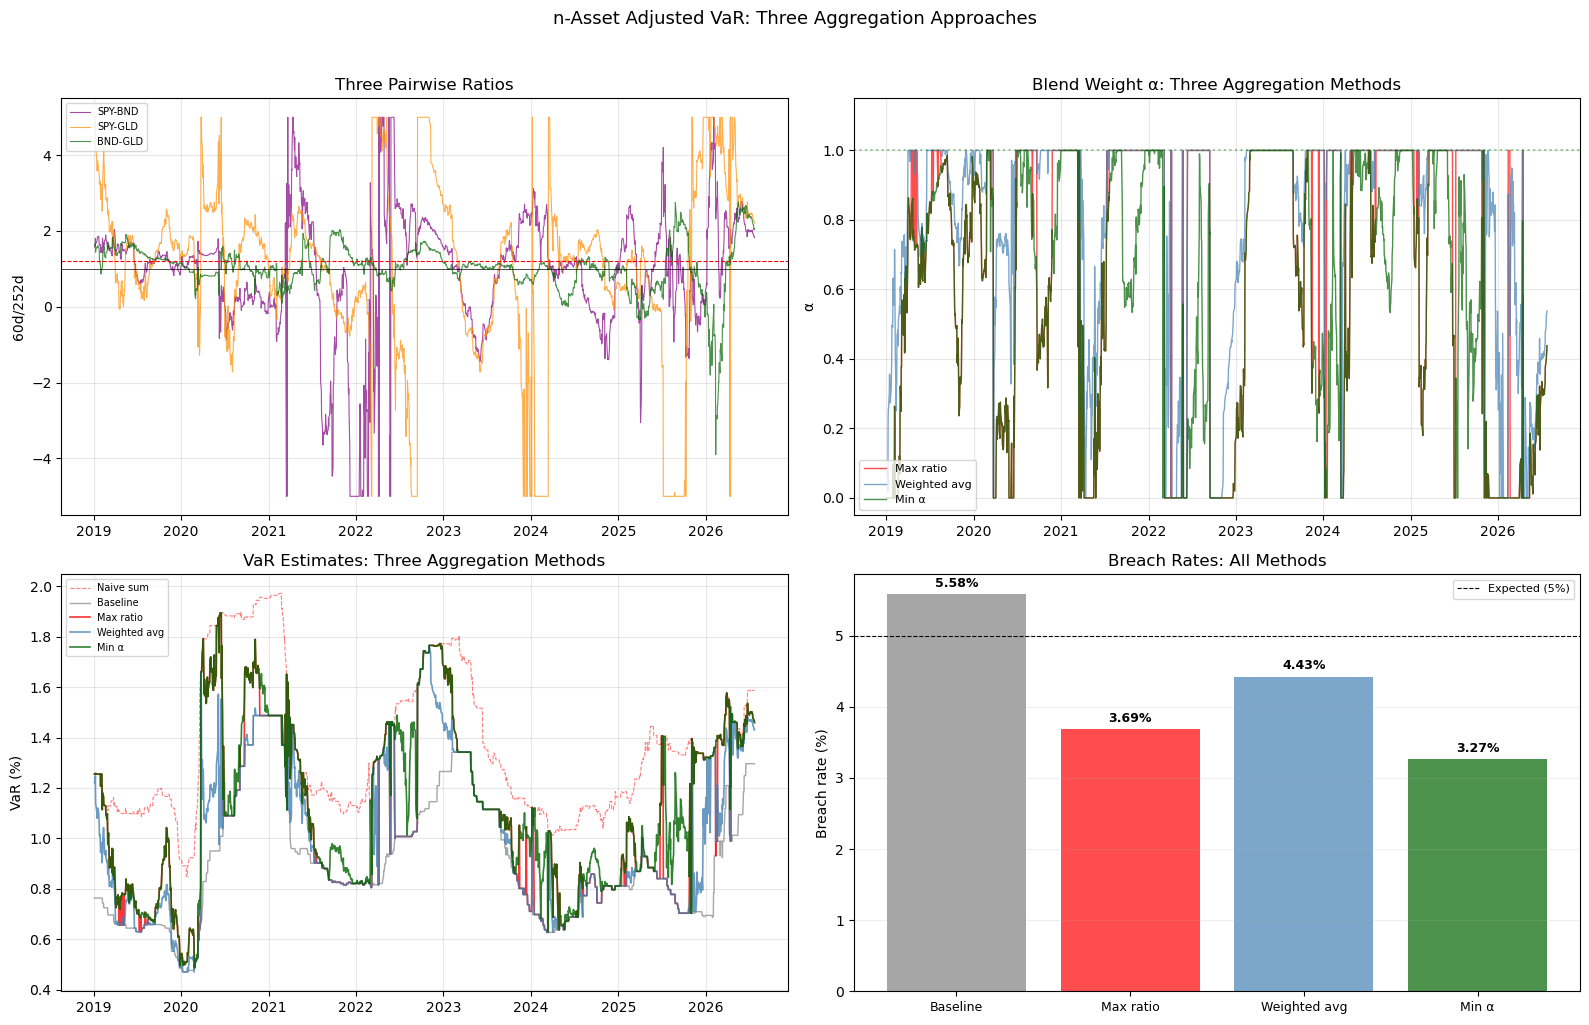

In [13]:
# Visual: all three aggregation methods vs baseline
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: The three ratios
ax = axes[0, 0]
for (label, ratio), color in zip(ratios.items(), colors):
    ax.plot(ratio.index, ratio.clip(-5, 5), color=color, linewidth=0.8, alpha=0.7, label=label)
ax.axhline(y=1.0, color="black", linestyle="-", linewidth=0.5)
ax.axhline(y=ASYM_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
ax.set_ylabel("60d/252d")
ax.set_title("Three Pairwise Ratios")
ax.legend(fontsize=7, loc="upper left")
ax.grid(True, alpha=0.3)

# Panel 2: α from each method
ax = axes[0, 1]
ax.plot(alpha_max.index, alpha_max, color="red", linewidth=1, alpha=0.7, label="Max ratio")
ax.plot(alpha_wavg.index, alpha_wavg, color="steelblue", linewidth=1, alpha=0.7, label="Weighted avg")
ax.plot(alpha_min.index, alpha_min, color="darkgreen", linewidth=1, alpha=0.7, label="Min α")
ax.axhline(y=1.0, color="green", linestyle=":", alpha=0.4)
ax.set_ylabel("α")
ax.set_ylim(-0.05, 1.15)
ax.set_title("Blend Weight α: Three Aggregation Methods")
ax.legend(fontsize=8, loc="lower left")
ax.grid(True, alpha=0.3)

# Panel 3: VaR comparison
ax = axes[1, 0]
ax.plot(naive.index, naive * 100, color="red", linestyle="--", linewidth=0.8, alpha=0.5,
        label="Naive sum")
ax.plot(baseline_var.index, baseline_var * 100, color="gray", linewidth=1, alpha=0.7,
        label="Baseline")
ax.plot(adj_max.index, adj_max * 100, color="red", linewidth=1.2, alpha=0.8,
        label="Max ratio")
ax.plot(adj_wavg.index, adj_wavg * 100, color="steelblue", linewidth=1.2, alpha=0.8,
        label="Weighted avg")
ax.plot(adj_min.index, adj_min * 100, color="darkgreen", linewidth=1.2, alpha=0.8,
        label="Min α")
ax.set_ylabel("VaR (%)")
ax.set_title("VaR Estimates: Three Aggregation Methods")
ax.legend(fontsize=7, loc="upper left")
ax.grid(True, alpha=0.3)

# Panel 4: Breach rates
ax = axes[1, 1]
names_n = [m[0] for m in methods_n]
rates_n = [m[2].sum()/n * 100 for m in methods_n]
x = np.arange(len(names_n))
bars = ax.bar(x, rates_n, color=["gray", "red", "steelblue", "darkgreen"], alpha=0.7)
ax.axhline(y=expected_rate*100, color="black", linestyle="--", linewidth=0.8,
          label=f"Expected ({expected_rate*100:.0f}%)")
ax.set_ylabel("Breach rate (%)")
ax.set_title("Breach Rates: All Methods")
ax.set_xticks(x)
ax.set_xticklabels(names_n, fontsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')

# Annotate bars
for bar, rate in zip(bars, rates_n):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{rate:.2f}%", ha='center', fontsize=9, fontweight='bold')

plt.suptitle("n-Asset Adjusted VaR: Three Aggregation Approaches", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Interpreting the aggregation results

**Max ratio:** Uses only the most extreme pair. Simple, explainable. "Which pair is worst right now?" But throws away information from the other pairs.

**Weighted average:** Weights each pair by $w_i w_j$ — how much that pair actually contributes to the portfolio. A pair with tiny weights (small allocation) gets small influence even if its correlation is spiking. More nuanced, but can dilute a strong signal from a small-position pair.

**Min α:** The most conservative. "If *any* pair says adjust, adjust." With 3 assets, this can mean a single noisy ratio drives the adjustment. With 10+ assets, it would be constantly adjusting — the probability that at least one pair looks elevated by chance is high.

**For this 3-asset portfolio:** the empirical winner tells you which approach works best for this specific combination. For different assets or periods, re-run the comparison.

---

## Part E: What scales and what doesn't

The honest assessment: most of the framework scales cleanly. The correlation monitoring explodes in dimensionality. The adjusted VaR aggregation is an open design question — solvable for 3 assets, increasingly fragile beyond that.

In [14]:
# Build the scaling summary table
scaling_table = pd.DataFrame({
    "Concept": [
        "Portfolio return",
        "All five VaR methods",
        "Naive sum",
        "Diversification benefit",
        "Marginal benefit (drop-one-out)",
        "Correlation monitoring",
        "Adjusted VaR",
    ],
    "2-asset": [
        "$w_1 r_1 + w_2 r_2$",
        "Works on portfolio returns",
        "$w_1$VaR$_1$ + $w_2$VaR$_2$",
        "$(S - V_p) / S$",
        "N/A (only one pair)",
        "1 ratio",
        "1 ratio → 1 α → 1 blend",
    ],
    "n-asset": [
        "$\\sum w_i r_i$",
        "Same — no changes needed",
        "$\\sum w_i$VaR$_i$",
        "Same formula",
        "Drop-one-out per asset",
        f"$n(n-1)/2$ ratios (={len(pairs)} for n={len(TICKERS)})",
        "$n(n-1)/2$ ratios → ?",
    ],
    "Assessment": [
        "✅ Trivial",
        "✅ Trivial",
        "✅ Trivial",
        "✅ Trivial",
        "✅ Straightforward",
        "⚠️ Monitoring complexity",
        "❓ Open design question",
    ],
})
display(scaling_table.style.hide(axis="index"))

Concept,2-asset,n-asset,Assessment
Portfolio return,$w_1 r_1 + w_2 r_2$,$\sum w_i r_i$,✅ Trivial
All five VaR methods,Works on portfolio returns,Same — no changes needed,✅ Trivial
Naive sum,$w_1$VaR$_1$ + $w_2$VaR$_2$,$\sum w_i$VaR$_i$,✅ Trivial
Diversification benefit,$(S - V_p) / S$,Same formula,✅ Trivial
Marginal benefit (drop-one-out),N/A (only one pair),Drop-one-out per asset,✅ Straightforward
Correlation monitoring,1 ratio,$n(n-1)/2$ ratios (=3 for n=3),⚠️ Monitoring complexity
Adjusted VaR,1 ratio → 1 α → 1 blend,$n(n-1)/2$ ratios → ?,❓ Open design question


### Why the adjusted VaR doesn't scale cleanly

The problem isn't computational — computing $α$ from $n(n-1)/2$ ratios is fast. The problem is **information quality**:

- With 2 assets, the ratio tells you one clear thing: "SPY-BND correlation has shifted."
- With 10 assets (45 ratios), you have 45 signals — many of which are noise, driven by the same underlying factors, or relevant to tiny position pairs.
- Aggregating 45 noisy signals into one $α$ washes out the signal-to-noise ratio.

**The practical answer:** for n > 3, the correlation matrix is more valuable as a monitoring dashboard than as a formula input. A risk manager scanning which pairs are spiking has more context than any weighted average of 45 ratios.

---

## Part F: Practical recommendations

### When to use each aggregation method

| Portfolio size | Recommendation | Rationale |
|---------------|---------------|-----------|
| **2 assets** | Asymmetric blend with the best pair ratio (Notebook 15b) | One clean signal. Optimal parameters are empirically testable. |
| **3 assets** | Test all three aggregation methods; pick the winner | The empirical comparison (Part D) tells you which works for your specific assets. |
| **4-10 assets** | Max-ratio method (simple, explainable) | The weighted average adds complexity without guaranteed improvement. Min-$α$ is too conservative — constant false alarms. |
| **10+ assets** | Matrix as monitoring dashboard, not formula input | Aggregating 45+ noisy ratios into one $α$ washes out signal. A risk manager scanning which pairs are spiking has more context. |

### When to re-calibrate

- Quarterly (routine health check)
- After a major correlation regime change
- When adding or removing assets — re-run the drop-one-out to understand the marginal impact

### Limitations

| Limitation | Mitigation |
|-----------|------------|
| Pairwise ratios explode with n | For n > 10, monitor the most extreme pairs, not all |
| Aggregation washes out signal for large n | Max-ratio method preserves the strongest signal |
| Drop-one-out is $O(n)$ to compute | Fast for n < 100. For larger n, use PCA or factor models (future work) |
| All the usual historical VaR limitations still apply | Parametric and Monte Carlo phases address these separately |

---

## Key takeaways

1. **The framework scales.** Portfolio return = weighted sum. All five VaR methods, naive sum, and diversification benefit work without modification. The computation is trivial.
2. **The new complexity is monitoring.** $n(n-1)/2$ pairwise correlation ratios replace the single ratio from the 2-asset case. The question shifts from "is correlation shifting?" to "*which pairs* are shifting?"
3. **Drop-one-out reveals which assets earn their keep.** The total benefit number hides composition. Marginal analysis shows which assets are diversification workhorses and which are dead weight.
4. **Three aggregation methods, no universal winner.** Max ratio is simple and preserves the strongest signal. Weighted average is more nuanced but can dilute. Min $α$ is too conservative for n > 3. The empirical comparison (Part D) picks the winner for your specific assets.
5. **For large n, the matrix is a dashboard, not a formula input.** Aggregating 45+ pairwise ratios into one $α$ washes out signal. A risk manager scanning which pairs are spiking has more context than any automated blend.
6. **The three-component framework (baseline + detector + blend) is the unifying pattern.** The implementation details change with n, but the architecture doesn't.